# Phase 5 — Scenario Simulator

**Purpose: PPT demo only.** Lets a presenter pick a risk threshold (or a risk level) and see how many zones would be flagged and what interventions that implies, using the real validation-set risk scores computed by `backend/app/models/generate_phase5_artifacts.py`. No retraining — frozen models, frozen feature set (Phase 4 lock).

In [1]:
import sys
sys.path.insert(0, "../../backend")

import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier, CatBoostRegressor

from app.models.classifier import build_classification_dataset
from app.models.feature_set import CATEGORICAL_FEATURES, NUMERIC_FEATURES
from app.models.recommendation import load_rules, recommend
from app.models.risk_score import RiskMinMaxParams, compute_risk_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

features = pd.read_parquet("../../data/processed/features.parquet")
targets = pd.read_parquet("../../data/processed/targets.parquet")
split = build_classification_dataset(features, targets)
feature_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES

clf = CatBoostClassifier(); clf.load_model("../models/classifier_catboost.cbm")
reg = CatBoostRegressor(); reg.load_model("../models/regressor_catboost.cbm")
with open("../models/risk_minmax_params.json") as f:
    risk_params = RiskMinMaxParams(**json.load(f))
rules = load_rules()

X_val = split.val[feature_cols]
hotspot_proba = clf.predict_proba(X_val)[:, 1]
predicted_count = reg.predict(X_val)
risk_df = compute_risk_score(hotspot_proba, predicted_count, split.val, risk_params)
risk_df["h3_cell"] = split.val["h3_cell"].to_numpy()
risk_df["vehicle_type"] = split.val["vehicle_type"].to_numpy()
risk_df["junction_name"] = split.val["junction_name"].to_numpy()
risk_df["junction_historical_risk"] = split.val["junction_historical_risk"].to_numpy()

print(f"Loaded {len(risk_df):,} validation-period rows with computed risk scores.")
risk_df[["risk_score", "risk_band"]].describe(include="all")


Loaded 44,767 validation-period rows with computed risk scores.


,risk_score,risk_band
count,44767.000000,44767
unique,NaN,4
top,NaN,LOW
freq,NaN,26013
mean,31.478614,NaN
std,12.024104,NaN
min,3.560000,NaN
25%,22.850000,NaN
50%,31.510000,NaN
75%,40.200000,NaN


## Simulation inputs
Edit `THRESHOLD` and re-run to explore different operating points.

In [2]:
THRESHOLD = 45.0   # try 34.0 (LOW/MEDIUM boundary), 45.1 (MEDIUM/HIGH), 54.2 (HIGH/CRITICAL)

flagged = risk_df[risk_df["risk_score"] >= THRESHOLD]
zones_flagged = flagged["h3_cell"].nunique()
rows_flagged = len(flagged)

print(f"Threshold: {THRESHOLD}")
print(f"Rows flagged: {rows_flagged:,} / {len(risk_df):,} ({rows_flagged/len(risk_df)*100:.1f}%)")
print(f"Distinct zones (H3 cells) flagged: {zones_flagged:,} / {risk_df['h3_cell'].nunique():,}")


Threshold: 45.0
Rows flagged: 6,498 / 44,767 (14.5%)
Distinct zones (H3 cells) flagged: 25 / 1,423


## Interventions triggered at this threshold
Runs the actual recommendation engine (vehicle mix + junction history escalation rules) on every flagged row.

Interventions triggered at threshold 45.0:

Deploy enforcement         5316
Tow operation candidate    1100
Patrol                       82
Name: count, dtype: int64

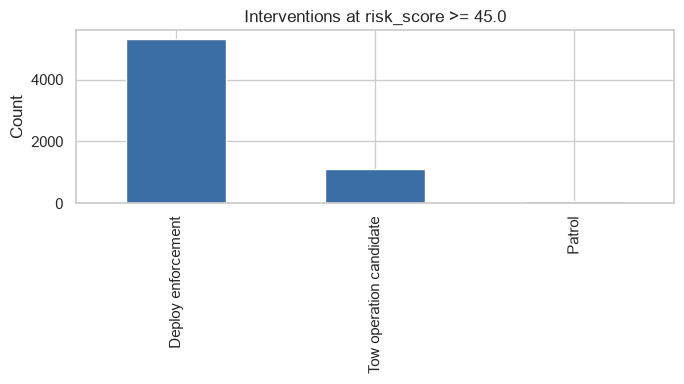

In [3]:
recs = [
    recommend(
        risk_band=row["risk_band"],
        vehicle_type=row["vehicle_type"],
        junction_name=row["junction_name"],
        junction_historical_risk=row["junction_historical_risk"],
        rules=rules,
    )
    for _, row in flagged.iterrows()
]
intervention_counts = pd.Series([r.final_action for r in recs]).value_counts()
print(f"Interventions triggered at threshold {THRESHOLD}:")
display(intervention_counts)

fig, ax = plt.subplots(figsize=(7, 4))
intervention_counts.plot(kind="bar", ax=ax, color="#3b6ea5")
ax.set_title(f"Interventions at risk_score >= {THRESHOLD}")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## Threshold sweep — zones flagged vs. interventions, across the full range
Shows the presenter how sensitive the system is to the chosen threshold (useful for picking a live operating point in a Q&A).

,threshold,rows_flagged,zones_flagged
0,10.0,43163,1062
1,20.0,36289,579
2,30.0,24675,256
3,34.0,18754,167
4,40.0,11408,62
5,45.1,6416,25
6,50.0,2847,10
7,54.2,1093,5
8,60.0,192,3
9,65.0,0,0


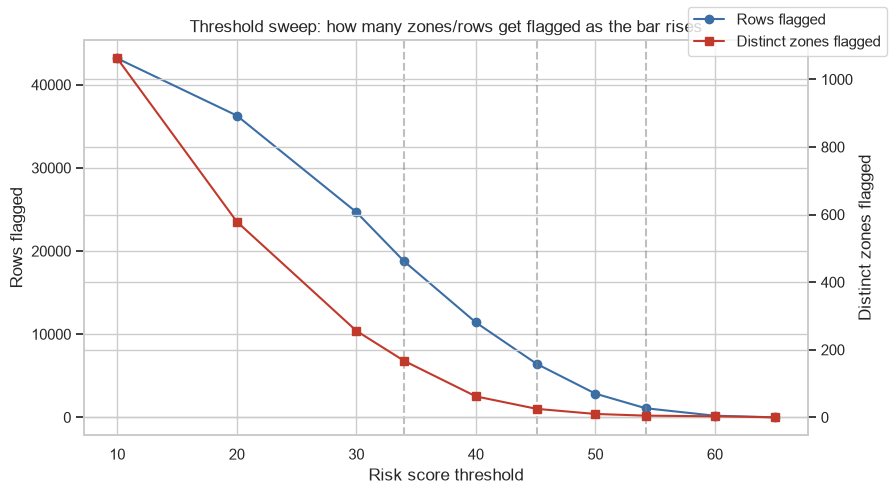

In [4]:
thresholds_to_try = [10, 20, 30, 34.0, 40, 45.1, 50, 54.2, 60, 65]
sweep_rows = []
for t in thresholds_to_try:
    subset = risk_df[risk_df["risk_score"] >= t]
    sweep_rows.append({
        "threshold": t,
        "rows_flagged": len(subset),
        "zones_flagged": subset["h3_cell"].nunique(),
    })
sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(sweep_df["threshold"], sweep_df["rows_flagged"], marker="o", color="#3b6ea5", label="Rows flagged")
ax1.set_xlabel("Risk score threshold")
ax1.set_ylabel("Rows flagged")
ax2 = ax1.twinx()
ax2.plot(sweep_df["threshold"], sweep_df["zones_flagged"], marker="s", color="#c0392b", label="Distinct zones flagged")
ax2.set_ylabel("Distinct zones flagged")
for band_edge, label in [(34.0, "LOW/MED"), (45.1, "MED/HIGH"), (54.2, "HIGH/CRIT")]:
    ax1.axvline(band_edge, linestyle="--", color="gray", alpha=0.5)
fig.legend(loc="upper right")
ax1.set_title("Threshold sweep: how many zones/rows get flagged as the bar rises")
plt.tight_layout()
plt.show()


## Scenario by risk LEVEL (band) instead of raw threshold
Equivalent simulation, but presented the way an operator would actually think about it: 'show me everything HIGH or above', not a raw number.

In [5]:
RISK_LEVEL = "HIGH"   # try LOW, MEDIUM, HIGH, CRITICAL

band_order = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]
min_band_idx = band_order.index(RISK_LEVEL)
bands_included = band_order[min_band_idx:]

level_flagged = risk_df[risk_df["risk_band"].isin(bands_included)]
print(f"Risk level >= {RISK_LEVEL}: {len(level_flagged):,} rows, "
      f"{level_flagged['h3_cell'].nunique():,} distinct zones")

level_recs = [
    recommend(
        risk_band=row["risk_band"],
        vehicle_type=row["vehicle_type"],
        junction_name=row["junction_name"],
        junction_historical_risk=row["junction_historical_risk"],
        rules=rules,
    )
    for _, row in level_flagged.iterrows()
]
display(pd.Series([r.final_action for r in level_recs]).value_counts())


Risk level >= HIGH: 6,416 rows, 25 distinct zones


Deploy enforcement         5316
Tow operation candidate    1100
Name: count, dtype: int64

## Conclusion (for the PPT)
- The simulator lets a presenter pick either a raw risk-score threshold or a named risk level and immediately see how many zones/rows would be flagged and what interventions that implies — useful for explaining the system's behavior to a non-technical audience without retraining anything.
- The threshold sweep shows the system's response is smooth and monotonic (no weird discontinuities), and the three band boundaries (34.0/45.1/54.2 — see `docs/risk_definition.md`) sit at meaningfully different points in that curve, not arbitrary cut lines.
- This notebook is a demo aid — it does not retrain, does not change the frozen feature set, and does not write back to any production artifact.